# **ATS Computer Vision**  
# Nama  : Kevin Rafael Owen
# NIM   : 4222301038
# Kelas : RE B PAGI

In [18]:
!pip3 install numpy matplotlib seaborn scikit-image scikit-learn 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score)

In [35]:
import os

In [36]:
os.chdir(r'C:\semester 6\Computer Vision RE604\ATS_RE604\Kevin_38')

---
## 1. Dataset Preparation

In [20]:
df = pd.read_csv('emnist-letters-train.csv')

raw_images = df.iloc[:, 1:].values.astype('uint8')
raw_labels = df.iloc[:, 0].values.astype('uint8')

raw_images = raw_images.reshape(-1, 28, 28)

print("Jumlah total gambar :", len(raw_images))
print("Jumlah total label  :", len(raw_labels))
print("Shape tiap gambar   :", raw_images[0].shape)

Jumlah total gambar : 88799
Jumlah total label  : 88799
Shape tiap gambar   : (28, 28)


In [21]:
raw_labels = raw_labels - 1

image_array = np.array(raw_images)
label_array = np.array(raw_labels)

In [22]:
NUM_SAMPLES_PER_CLASS = 100
NUM_CLASSES = 26

np.random.seed(42)

subset_images = []
subset_labels = []

for cls in range(NUM_CLASSES):
    class_indices = np.where(label_array == cls)[0]
    chosen = np.random.choice(class_indices, NUM_SAMPLES_PER_CLASS, replace=False)
    subset_images.append(image_array[chosen])
    subset_labels.append(label_array[chosen])

X_data = np.vstack(subset_images)
y_data = np.hstack(subset_labels)

# Shuffle dataset
shuffle_idx = np.random.permutation(len(X_data))
X_data = X_data[shuffle_idx]
y_data = y_data[shuffle_idx]

print(f"Total sampel setelah shuffle : {len(X_data)}")
print(f"Jumlah kelas                 : {NUM_CLASSES}")
print(f"Sampel per kelas             : {NUM_SAMPLES_PER_CLASS}")

Total sampel setelah shuffle : 2600
Jumlah kelas                 : 26
Sampel per kelas             : 100


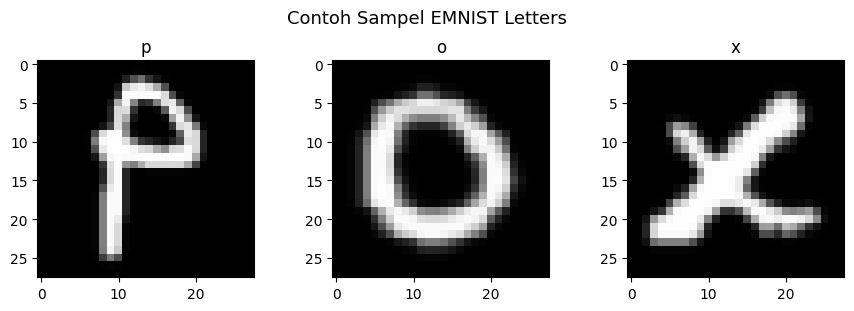

In [23]:
plt.figure(figsize=(9, 3))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_data[i].reshape(28, 28).T, cmap='gray')
    plt.title(chr(y_data[i] + 97), fontsize=12)
    plt.axis()

plt.suptitle('Contoh Sampel EMNIST Letters', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print(f"Training set : {X_train_raw.shape[0]} sampel (80%)")
print(f"Test set     : {X_test_raw.shape[0]} sampel (20%)")

Training set : 2080 sampel (80%)
Test set     : 520 sampel (20%)


---
## 2. Feature Extraction (HOG)

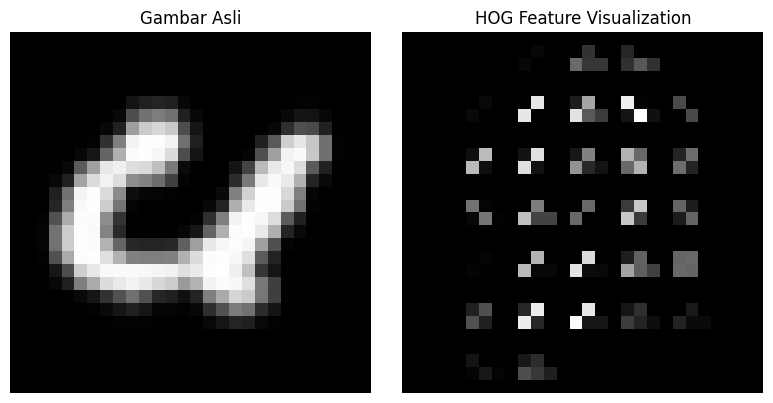

Dimensi vektor fitur HOG: (1296,)


In [25]:
sample_feat, sample_hog_img = hog(
    X_train_raw[0].reshape(28, 28),
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train_raw[0].reshape(28, 28).T, cmap='gray')
axes[0].set_title('Gambar Asli')
axes[0].axis('off')
axes[1].imshow(sample_hog_img, cmap='gray')
axes[1].set_title('HOG Feature Visualization')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Dimensi vektor fitur HOG:", sample_feat.shape)

In [26]:
class HOGExtractor:

    def __init__(self, orientations=9, pixels_per_cell=(4, 4),
                 cells_per_block=(2, 2), block_norm='L2-Hys'):
        self.orientations     = orientations
        self.pixels_per_cell  = pixels_per_cell
        self.cells_per_block  = cells_per_block
        self.block_norm       = block_norm

    def transform(self, images):
        features = []
        for img in images:
            feat = hog(
                img.reshape(28, 28),
                orientations=self.orientations,
                pixels_per_cell=self.pixels_per_cell,
                cells_per_block=self.cells_per_block,
                block_norm=self.block_norm
            )
            features.append(feat)
        return np.array(features)

In [27]:
hog_extractor = HOGExtractor(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)

X_train = hog_extractor.transform(X_train_raw)
X_test  = hog_extractor.transform(X_test_raw)

print("Shape fitur HOG — Training :", X_train.shape)
print("Shape fitur HOG — Test     :", X_test.shape)

Shape fitur HOG — Training : (2080, 1296)
Shape fitur HOG — Test     : (520, 1296)


---
## 3. Classification (SVM + GridSearchCV)

In [28]:
svm_param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'sigmoid'],
    'gamma'  : ['scale', 'auto']
}

In [29]:
base_svm = SVC(random_state=42)

grid_searcher = GridSearchCV(
    estimator=base_svm,
    param_grid=svm_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_searcher.fit(X_train, y_train)

print("\nParameter Terbaik  :", grid_searcher.best_params_)
print("Skor CV Terbaik    :", round(grid_searcher.best_score_, 4))

optimal_svm = grid_searcher.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Parameter Terbaik  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Skor CV Terbaik    : 0.8139


In [30]:
y_train_pred = optimal_svm.predict(X_train)
y_test_pred  = optimal_svm.predict(X_test)

print("Prediksi selesai.")
print(f"  Training : {len(y_train_pred)} sampel")
print(f"  Test     : {len(y_test_pred)} sampel")

Prediksi selesai.
  Training : 2080 sampel
  Test     : 520 sampel


---
## 4. Evaluation

In [31]:
class SVMEvaluator:
    """
    Kelas evaluasi performa model SVM.
    Menampilkan: Accuracy, Precision, Recall, F1-Score, Confusion Matrix.
    """
    def __init__(self, num_classes=26):
        self.num_classes   = num_classes
        self.letter_labels = [chr(i + 97) for i in range(num_classes)]

    def print_metrics(self, y_true, y_pred, dataset_name='Dataset'):
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        print("=" * 50)
        print(f"   EVALUASI — {dataset_name.upper()}")
        print("=" * 50)
        print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print("=" * 50)
        print(f"\nClassification Report ({dataset_name}):")
        print(classification_report(
            y_true, y_pred,
            target_names=self.letter_labels,
            zero_division=0
        ))

    def plot_confusion_matrix(self, y_true, y_pred, title='Confusion Matrix'):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(14, 11))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            xticklabels=self.letter_labels,
            yticklabels=self.letter_labels,
            linewidths=0.3
        )
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.title(title, fontsize=13)
        plt.tight_layout()
        plt.show()

    def plot_sample_predictions(self, images, y_true, y_pred, n=6):
        sample_idx = random.sample(range(len(images)), n)
        cols = 6
        rows = n // cols
        plt.figure(figsize=(16, rows * 2.5))
        for pos, idx in enumerate(sample_idx):
            plt.subplot(rows, cols, pos + 1)
            plt.imshow(images[idx].reshape(28, 28).T, cmap='gray')
            color = 'green' if y_true[idx] == y_pred[idx] else 'red'
            plt.title(
                f"T:{chr(y_true[idx]+97)} | P:{chr(y_pred[idx]+97)}",
                fontsize=9, color=color
            )
            plt.axis('off')
        plt.suptitle(
            'Prediksi Sampel — Hijau: Benar | Merah: Salah  (T=True, P=Predicted)',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

In [32]:
evaluator = SVMEvaluator(num_classes=26)
evaluator.print_metrics(y_test, y_test_pred, dataset_name='Test Set (20%)')

   EVALUASI — TEST SET (20%)
  Accuracy  : 0.8212  (82.12%)
  Precision : 0.8273
  Recall    : 0.8212
  F1-Score  : 0.8213

Classification Report (Test Set (20%)):
              precision    recall  f1-score   support

           a       0.73      0.80      0.76        20
           b       0.75      0.90      0.82        20
           c       0.82      0.90      0.86        20
           d       0.88      0.70      0.78        20
           e       0.80      0.60      0.69        20
           f       0.90      0.90      0.90        20
           g       0.50      0.40      0.44        20
           h       0.81      0.85      0.83        20
           i       0.56      0.70      0.62        20
           j       0.90      0.95      0.93        20
           k       0.89      0.80      0.84        20
           l       0.52      0.60      0.56        20
           m       0.95      1.00      0.98        20
           n       0.95      0.90      0.92        20
           o       1.00  

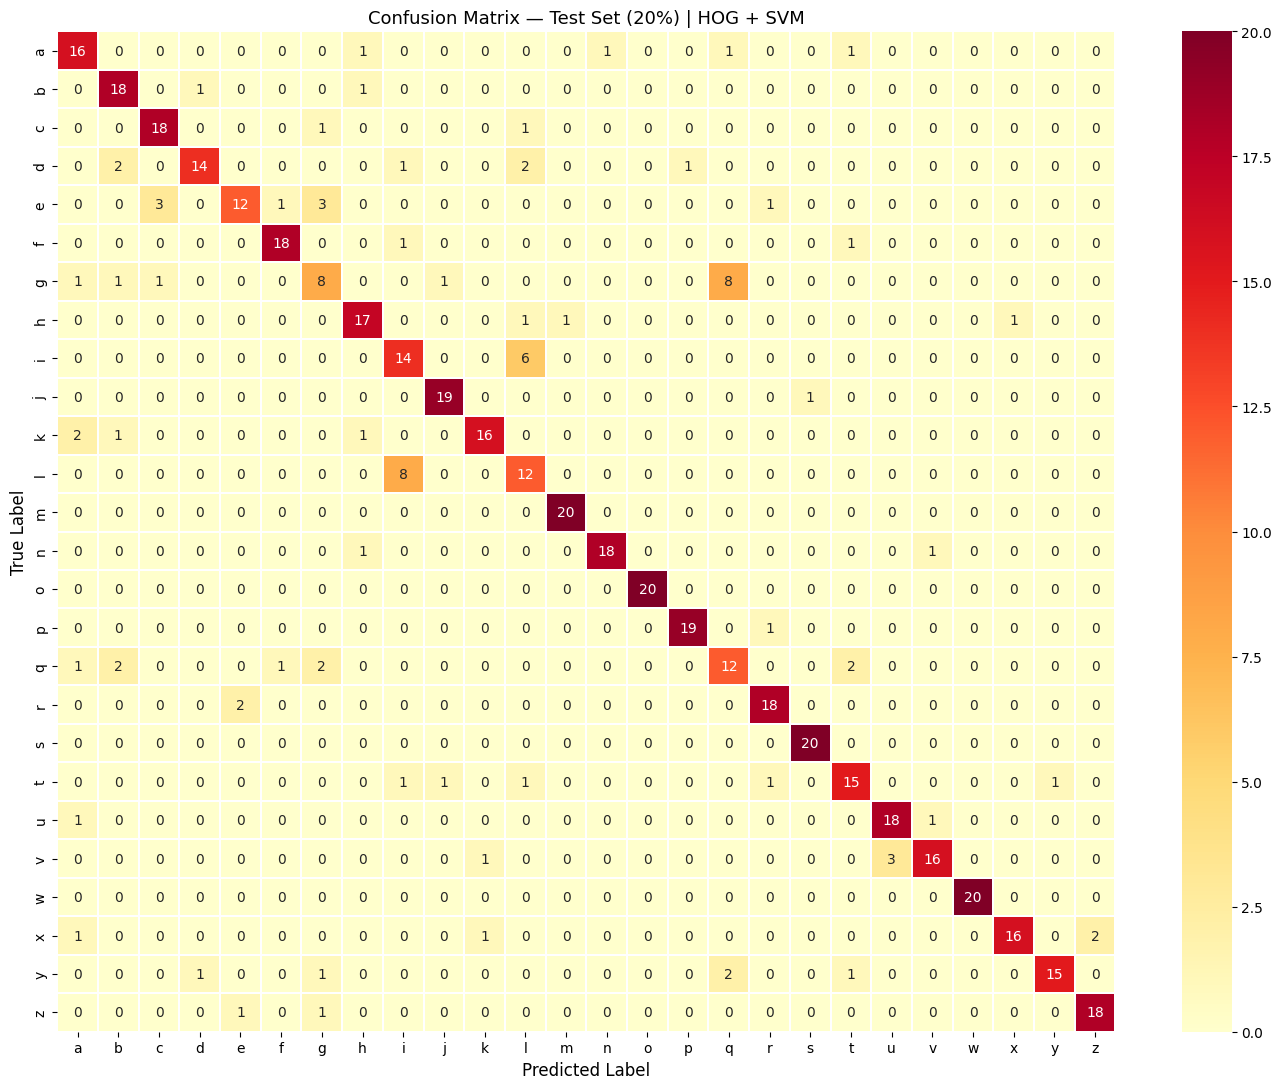

In [33]:
evaluator.plot_confusion_matrix(
    y_test, y_test_pred,
    title='Confusion Matrix — Test Set (20%) | HOG + SVM'
)

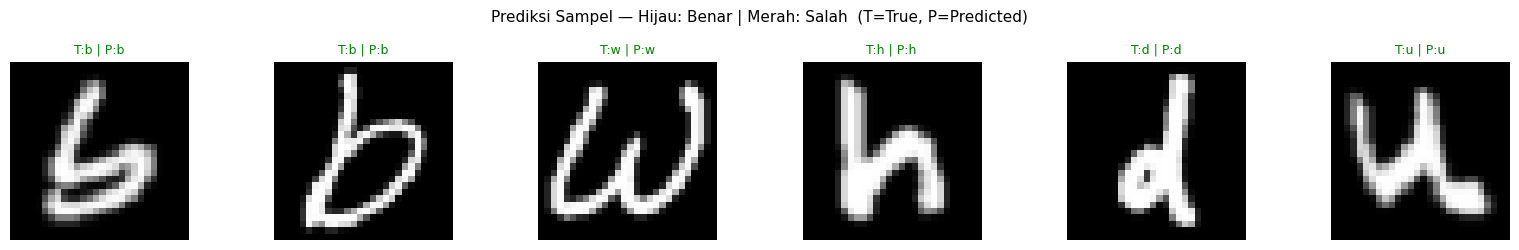

In [34]:
evaluator.plot_sample_predictions(
    X_test_raw, y_test, y_test_pred, n=6
)